In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D


from Greedy_SOSP import Greedy_SOSP
from utils.generate_graph import generate_graph

# incrementing node sizes twice the previous
NODE_SIZES = [4, 8, 16, 32, 64, 128, 256, 512, 1024]
EDGE_PROBS = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]  # edge probablity for nodes
REPEAT = 10  # repetation of 10


results = []  # for storing ablation results
# total no of running exp.
total_runs = len(NODE_SIZES)*len(EDGE_PROBS) * REPEAT

with tqdm(total=total_runs) as pbar:
    for n in NODE_SIZES:
        for prob in EDGE_PROBS:
            for r in range(REPEAT):
                # for each node having all the prob generate graph
                G = generate_graph(n, prob)

                # for each node and edge probablity, checking performance of greedy_sosp_update
                start = time.perf_counter()  # starting runtime
                Greedy_SOSP(G)  # greedy sosp algorithm running
                end = time.perf_counter()  # ending runtime
                runtime = end - start  # total runtime by algo

                # storing results
                results.append({
                    "nodes": n,
                    "edge_prob": prob,
                    "runtime": runtime
                })

                pbar.update(1)  # for updating tqdm


100%|██████████| 540/540 [19:10<00:00,  2.13s/it]  


In [2]:
df = pd.DataFrame(results)
df.to_csv('Greedy_SOSP_results.csv',  index=False)

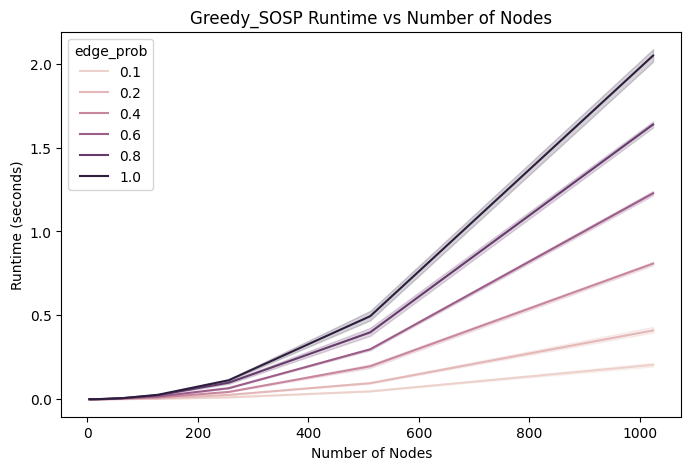

In [4]:
# run time vs nodes plot
plt.figure(figsize=(8, 5))

sns.lineplot(data=df,
             x="nodes",
             y="runtime",
             hue="edge_prob",
             estimator="mean")

plt.title("Greedy_SOSP Runtime vs Number of Nodes")
plt.xlabel("Number of Nodes")
plt.ylabel("Runtime (seconds)")

plt.show()


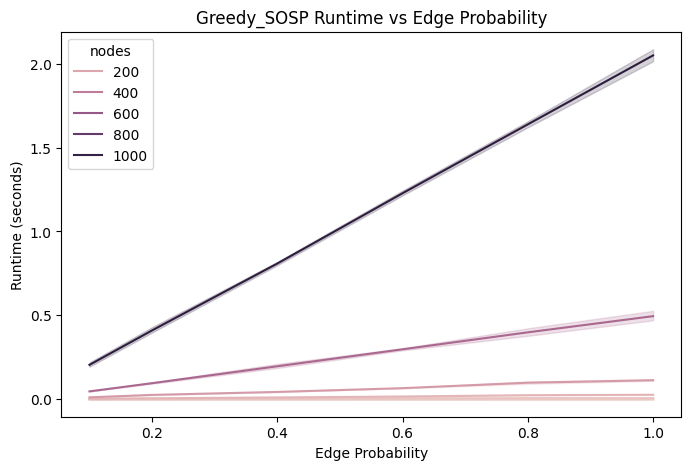

In [5]:
# runtime vs edge probablity
plt.figure(figsize=(8, 5))

sns.lineplot(data=df,
             x="edge_prob",
             y="runtime",
             hue="nodes",
             estimator="mean")

plt.title("Greedy_SOSP Runtime vs Edge Probability")
plt.xlabel("Edge Probability")
plt.ylabel("Runtime (seconds)")

plt.show()

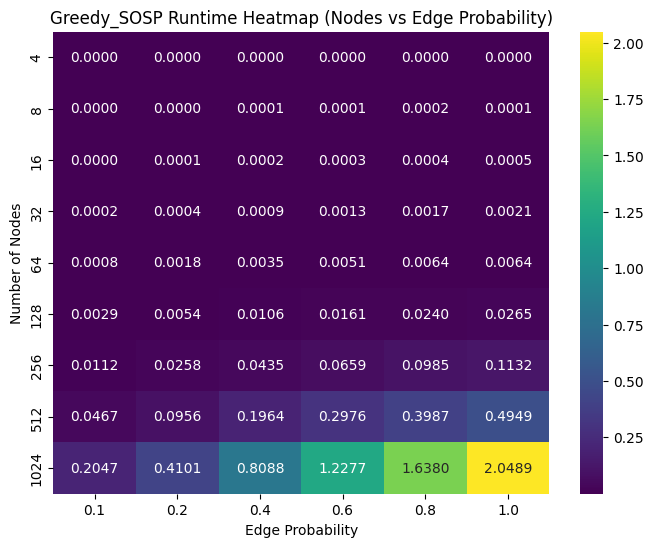

In [6]:
# heatmap n vs e
pivot = df.pivot_table(values="runtime",
                       index="nodes",
                       columns="edge_prob",
                       aggfunc=np.mean)

plt.figure(figsize=(8, 6))

sns.heatmap(pivot,
            annot=True,
            fmt=".4f",
            cmap="viridis")

plt.title("Greedy_SOSP Runtime Heatmap (Nodes vs Edge Probability)")
plt.xlabel("Edge Probability")
plt.ylabel("Number of Nodes")

plt.show()

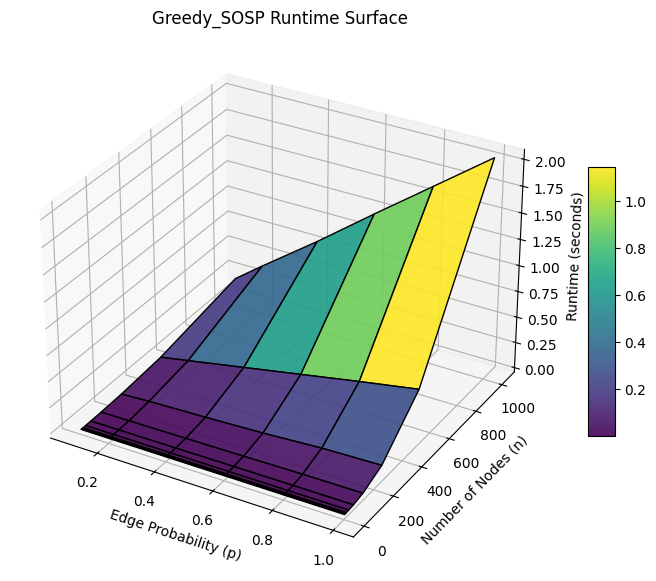

In [7]:

# a 3D representation of nodes, edge probablity and runtime

pivot = df.pivot_table(
    values="runtime",
    index="nodes",
    columns="edge_prob",
    aggfunc=np.mean
)

nodes = pivot.index.values
edge_probs = pivot.columns.values

X, Y = np.meshgrid(edge_probs, nodes)
Z = pivot.values

# X -> edge probablity
# Y -> node counts
# Z -> runtime


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(
    X, Y, Z,
    cmap='viridis',
    edgecolor='k',
    alpha=0.9
)

ax.set_xlabel("Edge Probability (p)")
ax.set_ylabel("Number of Nodes (n)")
ax.set_zlabel("Runtime (seconds)")
ax.set_title("Greedy_SOSP Runtime Surface")
fig.colorbar(surface, shrink=0.5, aspect=10)
# plt.savefig("runtime_surface_plot.png", dpi=300, bbox_inches="tight")

plt.show()

# Greedy_SOSP_Update Runtime Surface interpretation
# surface rises as nodes increases
# surface rises as edge probablity increases
# highest peak occurs as p = 1.0 and n = 1024
